# Olist Shipping and Delivered Performa Project

# 📌 Latar Belakang

Dalam bisnis e-commerce, kepuasan pelanggan sangat dipengaruhi oleh kecepatan dan ketepatan pengiriman barang. Salah satu tantangan terbesar adalah memastikan barang sampai sesuai estimasi, meskipun ada perbedaan lokasi geografis antara penjual (seller) dan pembeli (customer). Perbedaan kota/provinsi bisa memengaruhi biaya ongkir, lama pengiriman, hingga risiko keterlambatan.
Dengan memanfaatkan data transaksi (order, delivery date, estimasi, biaya, dan lokasi), perusahaan dapat menganalisis pola pengiriman serta mengidentifikasi faktor-faktor yang memengaruhi keterlambatan maupun kecepatan delivery.

# 📌 Tujuan Project

### Mengukur performa pengiriman

1. Melihat rata-rata waktu pengiriman (delivery time) dan keterlambatan (delay days).

### Menganalisis distribusi geografis
1. Membandingkan performa pengiriman berdasarkan lokasi customer (kota/provinsi) dan lokasi seller.
2. Mengidentifikasi wilayah dengan tingkat keterlambatan tinggi.

### Menilai hubungan faktor biaya & jarak dengan performa
1. Apakah ongkos kirim (freight_value) berbanding lurus dengan lama pengiriman?
2. Apakah order dengan jumlah item lebih banyak cenderung lebih lama terkirim?

In [1]:
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
import warnings

warnings.filterwarnings('ignore')

## Data Understanding

In [2]:
# Load dataset
olist = pd.read_csv("Project Olist/mastertable.csv")

olist.head()

,order_id,customers_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_city,seller_state
0,0198c71148c2e08c7c52b860f640fa4e,2938121a40a20953c43caa8c98787fcb,delivered,2018-05-08 06:34:07,2018-05-18 18:49:30,2018-05-29,sao paulo,SP,1,218d46b86c1881d022bce9c68a7d4b15,2018-05-15 04:31:23,148.00,15.13,ribeirao preto,SP
1,0330631bdb2ec8c341f487ed9c22fc8b,e3109970a3fe8021d5ff82c577ce5606,delivered,2018-05-25 12:02:08,2018-06-07 22:42:02,2018-06-26,sao paulo,SP,1,d2374cbcbb3ca4ab1086534108cc3ab7,2018-06-04 02:31:40,45.90,12.79,ibitinga,SP
2,00c47fefb9a49baec12ab3654d7f548e,411373e81bbd24b0356ca1274e9c03fe,delivered,2017-12-06 00:08:49,2018-01-16 21:05:08,2018-01-31,macapa,AP,1,91f0eec23d4a61d7d7caeefa3f0ad1ca,2017-12-13 00:18:33,199.00,67.69,tubarao,SC
3,02852b112ad108b3d2b3d4ee198d84a8,c45b7286a9a5cdce0152978d9f615be6,delivered,2017-11-25 11:58:17,2018-01-13 20:43:38,2017-12-22,salvador,BA,1,54965bbe3e4f07ae045b90b0b8541f52,2017-11-30 13:35:23,69.90,50.15,foz do iguacu,PR
4,01490a4bdacbafe6de009b317a0c8bf6,f9dfd7942a2d7f1588b7638a9bdc8ff1,delivered,2018-06-12 13:46:53,2018-06-21 23:38:52,2018-07-12,niteroi,RJ,1,ea67327e24487bdfac5fbfa37ea124df,2018-06-18 14:04:57,127.45,23.69,ibitinga,SP


In [3]:
olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       1000 non-null   object 
 1   customers_id                   1000 non-null   object 
 2   order_status                   1000 non-null   object 
 3   order_purchase_timestamp       1000 non-null   object 
 4   order_delivered_customer_date  1000 non-null   object 
 5   order_estimated_delivery_date  1000 non-null   object 
 6   customer_city                  1000 non-null   object 
 7   customer_state                 1000 non-null   object 
 8   order_item_id                  1000 non-null   int64  
 9   seller_id                      1000 non-null   object 
 10  shipping_limit_date            1000 non-null   object 
 11  price                          1000 non-null   float64
 12  freight_value                  1000 non-null   fl

- **Order Status** harusnya category
- **order_purchase_timestamp, order_delivered_customer_date, dan order_estimated_delivery_date** harusnya date/datetime


### Keterangan variabel:
1. **order_id**: ID (nomor unik) untuk setiap order
2. **customer_id**: ID (nomor unik) customer
3. **order_status**: status order
4. **order_purchased_timestamp**: waktu ketika order dibuat oleh customer
5. **order_delivered_customer_date**: waktu ketika order diterima oleh customer
6. **order_estimated_delivery_date**: estimasi waktu order diterima oleh customer
7. **customer_city**: kota customer
8. **customer_state**: State customer di Brazil
9. **order_item_id**: nomor urut item di dalam satu order, bukan jumlah total item.
10. **seller_id**: ID (nomor unik) seller
11. **shipping_limit_date**: Batas waktu seller harus mengirim item ke pihak logistik.
12. **price**: Harga item (tanpa ongkir), dalam BRL.
13. **freight_value**: Biaya ongkos kirim
14. **seller_city**: kota seller (penjual)
15. **seller_state**: state seller (penjual)

In [4]:
olist.shape

(1000, 15)

In [5]:
# Cek Missing Value
print(olist.isnull().sum())

# Persentase Missing Value
print(olist.isnull().mean().round(4)*100)

order_id                         0
customers_id                     0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_city                    0
customer_state                   0
order_item_id                    0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
seller_city                      0
seller_state                     0
dtype: int64
order_id                         0.0
customers_id                     0.0
order_status                     0.0
order_purchase_timestamp         0.0
order_delivered_customer_date    0.0
order_estimated_delivery_date    0.0
customer_city                    0.0
customer_state                   0.0
order_item_id                    0.0
seller_id                        0.0
shipping_limit_date              0.0
price                            0.0
freight_value     

Tidak ada missing value

In [6]:
# Cek duplikasi
duplicated = olist.duplicated().sum()
print(duplicated)

0


tidak ada duplikasi data

In [7]:
# hanya numeric
olist.describe()

,order_item_id,price,freight_value
count,1000.000000,1000.000000,1000.000000
mean,1.146000,112.648300,19.766360
std,0.448202,163.197112,14.816453
min,1.000000,3.490000,0.000000
25%,1.000000,39.900000,12.885000
50%,1.000000,71.950000,16.110000
75%,1.000000,129.967500,20.832500
max,5.000000,2649.990000,165.320000


Mayoritas customer melakukan pembelian (order) sebanyak 1 item, ada juga customer yang order hingga 5 item. Item yang dibeli customer rata-rata berada di harga 112,6 dengan rata-rata ongkos kirim 19,76, tetapi di beberapa order ongkos kirim mencapai 165.

In [8]:
# untuk kolom kategorikal
print(olist.describe(include="object"))

                                order_id                      customers_id  \
count                               1000                              1000   
unique                               884                               884   
top     02e0c2efb6d9bb2a95ca90b7e78bec1f  0b8eb01b2a378b535126bdf817eb1761   
freq                                   5                                 5   

       order_status order_purchase_timestamp order_delivered_customer_date  \
count          1000                     1000                          1000   
unique            4                      884                           871   
top       delivered      2018-04-01 10:50:46           0000-00-00 00:00:00   
freq            986                        5                            14   

       order_estimated_delivery_date customer_city customer_state  \
count                           1000          1000           1000   
unique                           340           358             25   
top        

Ada order / customer yang muncul lebih dari sekali, kemungkinan karena satu order punya lebih dari satu item (sesuai struktur data Olist).

- Ada 4 kategori status order. Sekitar 98,6% order yang sudah terkirim (delivered)
- Ada data anomali di order_delivered_customer_date 0000-00-00 00:00:00 yang muncul sebanyak 14x
- Lokasi dominan → pelanggan dan seller banyak di São Paulo → bisa menyebabkan bias analisis.
- Multiple items per order → terlihat dari order_id/customer_id yang muncul lebih dari sekali.

In [9]:
# Distribusi order status
olist['order_status'].value_counts()

order_status
delivered    986
shipped        8
canceled       5
invoiced       1
Name: count, dtype: int64

986 order berhasil terkirim, 8 order dalam pengiriman, 5 order cancel, dan 1 order invoiced.

In [10]:
# Distribusi customer state
print(olist["customer_state"].value_counts().head(10))

customer_state
SP    436
RJ    142
MG     97
RS     56
PR     47
SC     37
BA     36
DF     29
GO     27
CE     15
Name: count, dtype: int64


- Distribusi pada SP sangat tinggi, sehingga menunjukkan SP sebagai pusat aktivitas belanja online
- Karena SP terlalu dominan, analisis yang di-aggregate (misal rata-rata waktu pengiriman nasional) kemungkinan lebih merefleksikan kondisi SP ketimbang kondisi seluruh Brazil.
- Jika ingin menilai performa pengiriman per wilayah, analisis per state lebih adil ketimbang langsung menyamaratakan.

### Insight awal untuk bisnis
Walaupun SP merupakan pusat aktivitas belanja online, tetapi adanya order dari state lain menunjukkan bahwa Olist sudah menambah wilayah cakupan yang lebih luas. Jadi, bisa jadi peluang untuk menambah strategi logistik yang dapat mencakup state-state lain dengan maksimal.

In [11]:
# Distribusi seller state
print(olist["seller_state"].value_counts())

seller_state
SP    714
PR     83
MG     75
RJ     42
SC     32
RS     21
DF     14
ES      4
BA      4
MA      3
GO      2
PE      2
CE      1
RN      1
MT      1
RO      1
Name: count, dtype: int64


- Sama seperti di pelanggan, dominan SP bisa menimbulkan bias. Misalnya, kalau analisis performa pengiriman → hasilnya bisa lebih mencerminkan kondisi seller di SP, bukan nasional.
- Konsentrasi seller di SP bisa memengaruhi kecepatan pengiriman, terutama untuk pelanggan di SP (karena jarak seller–customer relatif dekat).

#### Insight Awal untuk Bisnis
- Olist (dan e-commerce lain) bisa mempertimbangkan pemerataan distribusi seller di luar SP.
- Jika seller hanya terkonsentrasi di satu wilayah, biaya logistik dan waktu pengiriman ke luar SP akan lebih tinggi.
- Potensi strategi: dorong seller dari wilayah non-SP untuk bergabung → memperluas jangkauan pasar + menurunkan biaya pengiriman.


**Apakah pengiriman diluar SP sudah maksimal?**

# Data Preparation

In [48]:
olist.dropna()

,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,price,freight_value,seller_city,seller_state,delivered_flag,delivery_time,delay_days,item_count
0,delivered,2018-05-08 06:34:07,2018-05-18 18:49:30,2018-05-29,sao paulo,SP,148.00,15.13,ribeirao preto,SP,True,10.0,-11.0,1
1,delivered,2018-05-25 12:02:08,2018-06-07 22:42:02,2018-06-26,sao paulo,SP,45.90,12.79,ibitinga,SP,True,13.0,-19.0,1
2,delivered,2017-12-06 00:08:49,2018-01-16 21:05:08,2018-01-31,macapa,AP,199.00,67.69,tubarao,SC,True,41.0,-15.0,1
3,delivered,2017-11-25 11:58:17,2018-01-13 20:43:38,2017-12-22,salvador,BA,69.90,50.15,foz do iguacu,PR,True,49.0,22.0,1
4,delivered,2018-06-12 13:46:53,2018-06-21 23:38:52,2018-07-12,niteroi,RJ,127.45,23.69,ibitinga,SP,True,9.0,-21.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,delivered,2018-08-17 23:15:06,2018-08-28 18:12:12,2018-08-31,passo fundo,RS,39.97,18.38,blumenau,SC,True,10.0,-3.0,3
996,delivered,2018-08-17 23:15:06,2018-08-28 18:12:12,2018-08-31,passo fundo,RS,39.97,18.38,blumenau,SC,True,10.0,-3.0,3
997,delivered,2018-04-16 13:14:09,2018-04-19 16:37:46,2018-05-02,sao paulo,SP,109.99,23.25,sao paulo,SP,True,3.0,-13.0,3
998,delivered,2018-04-16 13:14:09,2018-04-19 16:37:46,2018-05-02,sao paulo,SP,38.90,16.56,sao paulo,SP,True,3.0,-13.0,3


### Transormasi ke datetime

In [12]:
# daftar kolom tanggal yang penting
date_cols = [
    "order_purchase_timestamp", 
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

# ubah jadi datetime, invalid → NaT
for col in date_cols:
    olist[col] = pd.to_datetime(olist[col], errors="coerce")

# cek jumlah missing value setelah konversi
olist[date_cols].isna().sum()

order_purchase_timestamp          0
order_delivered_customer_date    14
order_estimated_delivery_date     0
shipping_limit_date               0
dtype: int64

In [13]:
olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       1000 non-null   object        
 1   customers_id                   1000 non-null   object        
 2   order_status                   1000 non-null   object        
 3   order_purchase_timestamp       1000 non-null   datetime64[ns]
 4   order_delivered_customer_date  986 non-null    datetime64[ns]
 5   order_estimated_delivery_date  1000 non-null   datetime64[ns]
 6   customer_city                  1000 non-null   object        
 7   customer_state                 1000 non-null   object        
 8   order_item_id                  1000 non-null   int64         
 9   seller_id                      1000 non-null   object        
 10  shipping_limit_date            1000 non-null   datetime64[ns]
 11  price             

In [14]:
olist.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value
count,1000,986,1000,1000.000000,1000,1000.000000,1000.000000
mean,2017-12-30 17:55:33.696999936,2018-01-11 22:41:47.349898496,2018-01-22 20:26:52.800000,1.146000,2018-01-06 03:31:47.724000,112.648300,19.766360
min,2016-10-04 19:01:13,2016-10-31 17:06:03,2016-11-28 00:00:00,1.000000,2016-10-21 16:25:24,3.490000,0.000000
25%,2017-09-15 09:04:45.249999872,2017-09-26 20:10:14.500000,2017-10-04 00:00:00,1.000000,2017-09-21 13:39:02.750000128,39.900000,12.885000
50%,2018-01-14 12:07:28,2018-01-30 05:55:33,2018-02-06 12:00:00,1.000000,2018-01-19 05:03:38,71.950000,16.110000
75%,2018-04-26 08:46:02,2018-05-08 16:58:08.500000,2018-05-18 00:00:00,1.000000,2018-05-03 11:22:28.500000,129.967500,20.832500
max,2018-08-28 21:10:46,2018-08-31 02:12:04,2018-09-28 00:00:00,5.000000,2018-09-03 09:55:13,2649.990000,165.320000
std,NaN,NaN,NaN,0.448202,NaN,163.197112,14.816453


### Transformasi kolom order_status dari object menjadi category

In [15]:
olist['order_status'] = olist['order_status'].astype('category')

In [16]:
olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       1000 non-null   object        
 1   customers_id                   1000 non-null   object        
 2   order_status                   1000 non-null   category      
 3   order_purchase_timestamp       1000 non-null   datetime64[ns]
 4   order_delivered_customer_date  986 non-null    datetime64[ns]
 5   order_estimated_delivery_date  1000 non-null   datetime64[ns]
 6   customer_city                  1000 non-null   object        
 7   customer_state                 1000 non-null   object        
 8   order_item_id                  1000 non-null   int64         
 9   seller_id                      1000 non-null   object        
 10  shipping_limit_date            1000 non-null   datetime64[ns]
 11  price             

### Menambahkan Kolom delivery_flag

untuk menandakan orderan yang telah terkirim dan gagal terkirim (cancel)

In [17]:
# Flag order yang tidak terkirim
olist["delivered_flag"] = olist["order_delivered_customer_date"].notnull()

# Cek distribusi
print(olist["delivered_flag"].value_counts())


delivered_flag
True     986
False     14
Name: count, dtype: int64


True: orderan terkirim

False: orderan tidak terkirim

ada 14 order yang tidak terkirim/gagal terkirim

In [18]:
olist.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value
count,1000,986,1000,1000.000000,1000,1000.000000,1000.000000
mean,2017-12-30 17:55:33.696999936,2018-01-11 22:41:47.349898496,2018-01-22 20:26:52.800000,1.146000,2018-01-06 03:31:47.724000,112.648300,19.766360
min,2016-10-04 19:01:13,2016-10-31 17:06:03,2016-11-28 00:00:00,1.000000,2016-10-21 16:25:24,3.490000,0.000000
25%,2017-09-15 09:04:45.249999872,2017-09-26 20:10:14.500000,2017-10-04 00:00:00,1.000000,2017-09-21 13:39:02.750000128,39.900000,12.885000
50%,2018-01-14 12:07:28,2018-01-30 05:55:33,2018-02-06 12:00:00,1.000000,2018-01-19 05:03:38,71.950000,16.110000
75%,2018-04-26 08:46:02,2018-05-08 16:58:08.500000,2018-05-18 00:00:00,1.000000,2018-05-03 11:22:28.500000,129.967500,20.832500
max,2018-08-28 21:10:46,2018-08-31 02:12:04,2018-09-28 00:00:00,5.000000,2018-09-03 09:55:13,2649.990000,165.320000
std,NaN,NaN,NaN,0.448202,NaN,163.197112,14.816453


In [19]:
olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       1000 non-null   object        
 1   customers_id                   1000 non-null   object        
 2   order_status                   1000 non-null   category      
 3   order_purchase_timestamp       1000 non-null   datetime64[ns]
 4   order_delivered_customer_date  986 non-null    datetime64[ns]
 5   order_estimated_delivery_date  1000 non-null   datetime64[ns]
 6   customer_city                  1000 non-null   object        
 7   customer_state                 1000 non-null   object        
 8   order_item_id                  1000 non-null   int64         
 9   seller_id                      1000 non-null   object        
 10  shipping_limit_date            1000 non-null   datetime64[ns]
 11  price             

### Hapus Duplikasi

In [20]:
olist.drop_duplicates(subset=["order_id","order_item_id"], inplace=True)

In [21]:
olist.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value
count,1000,986,1000,1000.000000,1000,1000.000000,1000.000000
mean,2017-12-30 17:55:33.696999936,2018-01-11 22:41:47.349898496,2018-01-22 20:26:52.800000,1.146000,2018-01-06 03:31:47.724000,112.648300,19.766360
min,2016-10-04 19:01:13,2016-10-31 17:06:03,2016-11-28 00:00:00,1.000000,2016-10-21 16:25:24,3.490000,0.000000
25%,2017-09-15 09:04:45.249999872,2017-09-26 20:10:14.500000,2017-10-04 00:00:00,1.000000,2017-09-21 13:39:02.750000128,39.900000,12.885000
50%,2018-01-14 12:07:28,2018-01-30 05:55:33,2018-02-06 12:00:00,1.000000,2018-01-19 05:03:38,71.950000,16.110000
75%,2018-04-26 08:46:02,2018-05-08 16:58:08.500000,2018-05-18 00:00:00,1.000000,2018-05-03 11:22:28.500000,129.967500,20.832500
max,2018-08-28 21:10:46,2018-08-31 02:12:04,2018-09-28 00:00:00,5.000000,2018-09-03 09:55:13,2649.990000,165.320000
std,NaN,NaN,NaN,0.448202,NaN,163.197112,14.816453


In [22]:
duplicated = olist.duplicated().sum()
print(duplicated)

0


### Feature Engineering - Buat Kolom Baru

In [23]:
# delivery time dalam hari
olist["delivery_time"] = (olist["order_delivered_customer_date"] - olist["order_purchase_timestamp"]).dt.days

# delay_days: positif = terlambat, negatif = lebih cepat
olist["delay_days"] = (olist["order_delivered_customer_date"] - olist["order_estimated_delivery_date"]).dt.days

# item_count per order
item_count = olist.groupby("order_id")["order_item_id"].max().reset_index()
item_count.rename(columns={"order_item_id": "item_count"}, inplace=True)

# merge ke master
olist = olist.merge(item_count, on="order_id", how="left")


In [24]:
olist.head()

,order_id,customers_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_city,seller_state,delivered_flag,delivery_time,delay_days,item_count
0,0198c71148c2e08c7c52b860f640fa4e,2938121a40a20953c43caa8c98787fcb,delivered,2018-05-08 06:34:07,2018-05-18 18:49:30,2018-05-29,sao paulo,SP,1,218d46b86c1881d022bce9c68a7d4b15,2018-05-15 04:31:23,148.00,15.13,ribeirao preto,SP,True,10.0,-11.0,1
1,0330631bdb2ec8c341f487ed9c22fc8b,e3109970a3fe8021d5ff82c577ce5606,delivered,2018-05-25 12:02:08,2018-06-07 22:42:02,2018-06-26,sao paulo,SP,1,d2374cbcbb3ca4ab1086534108cc3ab7,2018-06-04 02:31:40,45.90,12.79,ibitinga,SP,True,13.0,-19.0,1
2,00c47fefb9a49baec12ab3654d7f548e,411373e81bbd24b0356ca1274e9c03fe,delivered,2017-12-06 00:08:49,2018-01-16 21:05:08,2018-01-31,macapa,AP,1,91f0eec23d4a61d7d7caeefa3f0ad1ca,2017-12-13 00:18:33,199.00,67.69,tubarao,SC,True,41.0,-15.0,1
3,02852b112ad108b3d2b3d4ee198d84a8,c45b7286a9a5cdce0152978d9f615be6,delivered,2017-11-25 11:58:17,2018-01-13 20:43:38,2017-12-22,salvador,BA,1,54965bbe3e4f07ae045b90b0b8541f52,2017-11-30 13:35:23,69.90,50.15,foz do iguacu,PR,True,49.0,22.0,1
4,01490a4bdacbafe6de009b317a0c8bf6,f9dfd7942a2d7f1588b7638a9bdc8ff1,delivered,2018-06-12 13:46:53,2018-06-21 23:38:52,2018-07-12,niteroi,RJ,1,ea67327e24487bdfac5fbfa37ea124df,2018-06-18 14:04:57,127.45,23.69,ibitinga,SP,True,9.0,-21.0,1


In [25]:
olist.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,delivery_time,delay_days,item_count
count,1000,986,1000,1000.000000,1000,1000.000000,1000.000000,986.000000,986.000000,1000.000000
mean,2017-12-30 17:55:33.696999936,2018-01-11 22:41:47.349898496,2018-01-22 20:26:52.800000,1.146000,2018-01-06 03:31:47.724000,112.648300,19.766360,11.694726,-11.669371,1.292000
min,2016-10-04 19:01:13,2016-10-31 17:06:03,2016-11-28 00:00:00,1.000000,2016-10-21 16:25:24,3.490000,0.000000,1.000000,-44.000000,1.000000
25%,2017-09-15 09:04:45.249999872,2017-09-26 20:10:14.500000,2017-10-04 00:00:00,1.000000,2017-09-21 13:39:02.750000128,39.900000,12.885000,6.000000,-17.000000,1.000000
50%,2018-01-14 12:07:28,2018-01-30 05:55:33,2018-02-06 12:00:00,1.000000,2018-01-19 05:03:38,71.950000,16.110000,9.000000,-12.000000,1.000000
75%,2018-04-26 08:46:02,2018-05-08 16:58:08.500000,2018-05-18 00:00:00,1.000000,2018-05-03 11:22:28.500000,129.967500,20.832500,14.000000,-8.000000,1.000000
max,2018-08-28 21:10:46,2018-08-31 02:12:04,2018-09-28 00:00:00,5.000000,2018-09-03 09:55:13,2649.990000,165.320000,166.000000,123.000000,5.000000
std,NaN,NaN,NaN,0.448202,NaN,163.197112,14.816453,10.267840,10.426256,0.659675


In [26]:
olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       1000 non-null   object        
 1   customers_id                   1000 non-null   object        
 2   order_status                   1000 non-null   category      
 3   order_purchase_timestamp       1000 non-null   datetime64[ns]
 4   order_delivered_customer_date  986 non-null    datetime64[ns]
 5   order_estimated_delivery_date  1000 non-null   datetime64[ns]
 6   customer_city                  1000 non-null   object        
 7   customer_state                 1000 non-null   object        
 8   order_item_id                  1000 non-null   int64         
 9   seller_id                      1000 non-null   object        
 10  shipping_limit_date            1000 non-null   datetime64[ns]
 11  price             

In [27]:
# Transformasi order_item_id menjadi object
olist['order_item_id'] = olist['order_item_id'].astype('object')

In [28]:
olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       1000 non-null   object        
 1   customers_id                   1000 non-null   object        
 2   order_status                   1000 non-null   category      
 3   order_purchase_timestamp       1000 non-null   datetime64[ns]
 4   order_delivered_customer_date  986 non-null    datetime64[ns]
 5   order_estimated_delivery_date  1000 non-null   datetime64[ns]
 6   customer_city                  1000 non-null   object        
 7   customer_state                 1000 non-null   object        
 8   order_item_id                  1000 non-null   object        
 9   seller_id                      1000 non-null   object        
 10  shipping_limit_date            1000 non-null   datetime64[ns]
 11  price             

In [29]:
print(olist.describe())

            order_purchase_timestamp  order_delivered_customer_date  \
count                           1000                            986   
mean   2017-12-30 17:55:33.696999936  2018-01-11 22:41:47.349898496   
min              2016-10-04 19:01:13            2016-10-31 17:06:03   
25%    2017-09-15 09:04:45.249999872     2017-09-26 20:10:14.500000   
50%              2018-01-14 12:07:28            2018-01-30 05:55:33   
75%              2018-04-26 08:46:02     2018-05-08 16:58:08.500000   
max              2018-08-28 21:10:46            2018-08-31 02:12:04   
std                              NaN                            NaN   

      order_estimated_delivery_date            shipping_limit_date  \
count                          1000                           1000   
mean     2018-01-22 20:26:52.800000     2018-01-06 03:31:47.724000   
min             2016-11-28 00:00:00            2016-10-21 16:25:24   
25%             2017-10-04 00:00:00  2017-09-21 13:39:02.750000128   
50%       

In [30]:
olist.shape

(1000, 19)

In [31]:
# Drop kolom yang tidak digunakan
olist = olist.drop(columns=["order_id", "customers_id", "order_item_id", 
                    "seller_id", "shipping_limit_date"])

In [32]:
olist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_status                   1000 non-null   category      
 1   order_purchase_timestamp       1000 non-null   datetime64[ns]
 2   order_delivered_customer_date  986 non-null    datetime64[ns]
 3   order_estimated_delivery_date  1000 non-null   datetime64[ns]
 4   customer_city                  1000 non-null   object        
 5   customer_state                 1000 non-null   object        
 6   price                          1000 non-null   float64       
 7   freight_value                  1000 non-null   float64       
 8   seller_city                    1000 non-null   object        
 9   seller_state                   1000 non-null   object        
 10  delivered_flag                 1000 non-null   bool          
 11  delivery_time     

In [33]:
olist.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,delivery_time,delay_days,item_count
count,1000,986,1000,1000.000000,1000.000000,986.000000,986.000000,1000.000000
mean,2017-12-30 17:55:33.696999936,2018-01-11 22:41:47.349898496,2018-01-22 20:26:52.800000,112.648300,19.766360,11.694726,-11.669371,1.292000
min,2016-10-04 19:01:13,2016-10-31 17:06:03,2016-11-28 00:00:00,3.490000,0.000000,1.000000,-44.000000,1.000000
25%,2017-09-15 09:04:45.249999872,2017-09-26 20:10:14.500000,2017-10-04 00:00:00,39.900000,12.885000,6.000000,-17.000000,1.000000
50%,2018-01-14 12:07:28,2018-01-30 05:55:33,2018-02-06 12:00:00,71.950000,16.110000,9.000000,-12.000000,1.000000
75%,2018-04-26 08:46:02,2018-05-08 16:58:08.500000,2018-05-18 00:00:00,129.967500,20.832500,14.000000,-8.000000,1.000000
max,2018-08-28 21:10:46,2018-08-31 02:12:04,2018-09-28 00:00:00,2649.990000,165.320000,166.000000,123.000000,5.000000
std,NaN,NaN,NaN,163.197112,14.816453,10.267840,10.426256,0.659675


## EDA

- kota kota mana saja dengan pengiriman yg lambat dan kota dengan pengiriman yang cepat?
- kota dengan customer terbanyak?
- dari mana aja orderan yang gagal (menampilkan informasi orderan yang gagal)
- Perbandingan pengiriman yang delay dengan yang tepat waktu

In [34]:
# --- 1. Info dasar dataset ---
print(olist.info())
print(olist.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_status                   1000 non-null   category      
 1   order_purchase_timestamp       1000 non-null   datetime64[ns]
 2   order_delivered_customer_date  986 non-null    datetime64[ns]
 3   order_estimated_delivery_date  1000 non-null   datetime64[ns]
 4   customer_city                  1000 non-null   object        
 5   customer_state                 1000 non-null   object        
 6   price                          1000 non-null   float64       
 7   freight_value                  1000 non-null   float64       
 8   seller_city                    1000 non-null   object        
 9   seller_state                   1000 non-null   object        
 10  delivered_flag                 1000 non-null   bool          
 11  delivery_time     

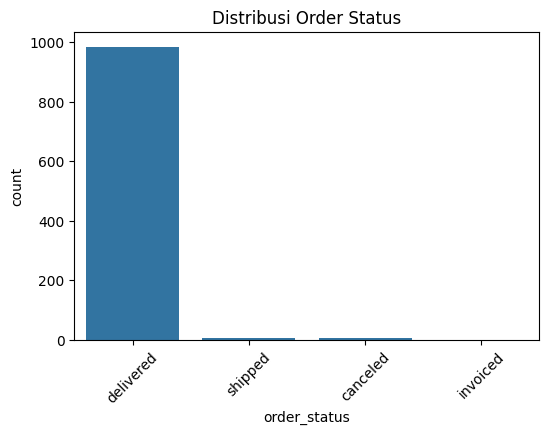

In [35]:
# --- 2. Distribusi status order ---
plt.figure(figsize=(6,4))
sns.countplot(data=olist, x="order_status", order=olist["order_status"].value_counts().index)
plt.title("Distribusi Order Status")
plt.xticks(rotation=45)
plt.show()

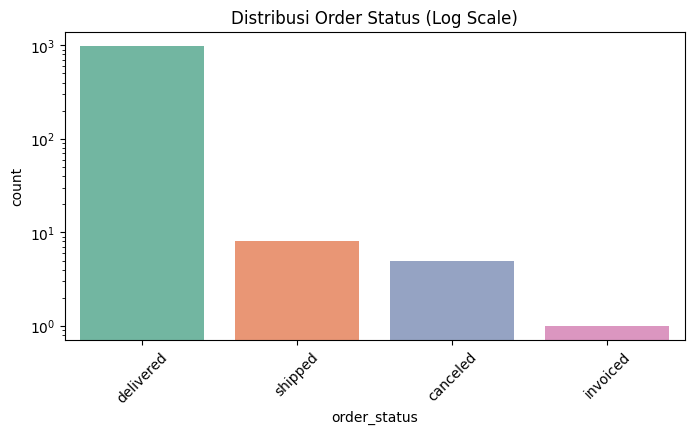

In [36]:
plt.figure(figsize=(8,4))
sns.countplot(data=olist, x="order_status", order=olist["order_status"].value_counts().index, palette="Set2")
plt.yscale("log")  # pakai log scale
plt.title("Distribusi Order Status (Log Scale)")
plt.xticks(rotation=45)
plt.show()

Sebagian besar status pengiriman adalah *delivered* yang artinya sistem pengiriman secara umum berjalan dengan baik. Namun, tedapat pesanan yang tidak terselesaikan atau dibatalkan. Meskipun jumlahnya sangat kecil, tetapi kasus-kasus ini tetap perlu untuk dianalisis guna memahami potensi masalah yang mungkin terjadi.

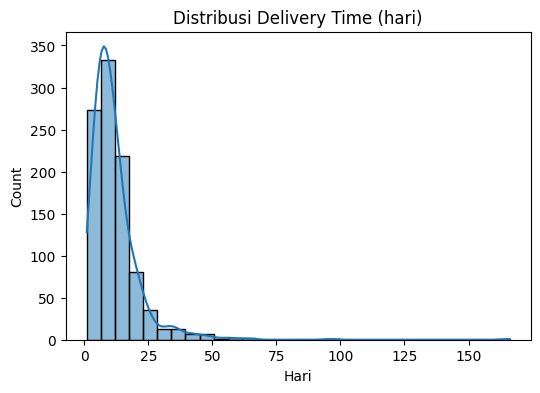

In [37]:
# --- 3. Distribusi waktu pengiriman ---
plt.figure(figsize=(6,4))
sns.histplot(olist["delivery_time"].dropna(), bins=30, kde=True)
plt.title("Distribusi Delivery Time (hari)")
plt.xlabel("Hari")
plt.show()

Sebagian besar orderan sampai ke tangan penerima dalam waktu yang relatif singkat, umumnya dibawah dua minggu. Namun, masih terdapat order yang pengirimannya mencapai 150 hari.

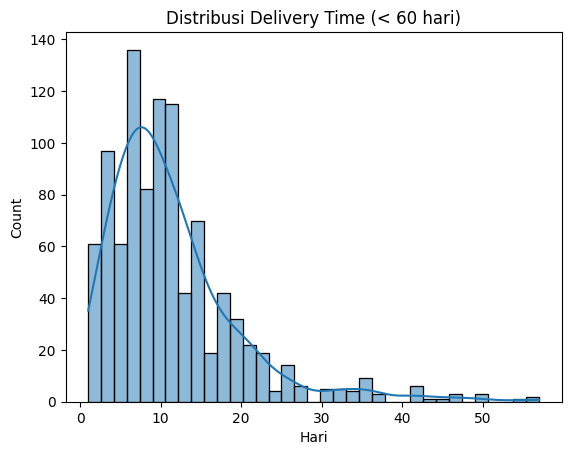

In [61]:
sns.histplot(data=olist[olist["delivery_time"] < 60], x="delivery_time", kde=True)
plt.title("Distribusi Delivery Time (< 60 hari)")
plt.xlabel("Hari")
plt.show()

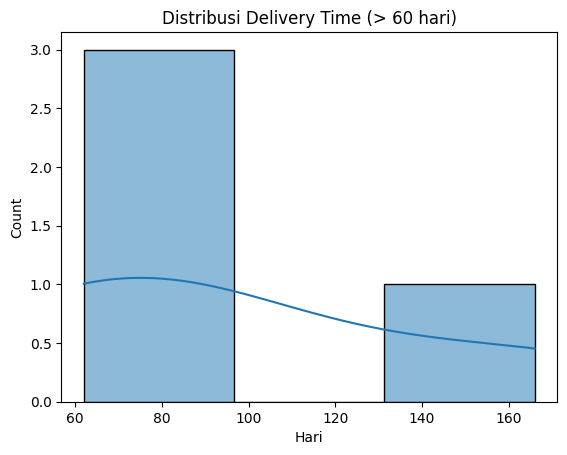

In [60]:
sns.histplot(data=olist[olist["delivery_time"] > 60], x="delivery_time", kde=True)
plt.title("Distribusi Delivery Time (> 60 hari)")
plt.xlabel("Hari")
plt.show()

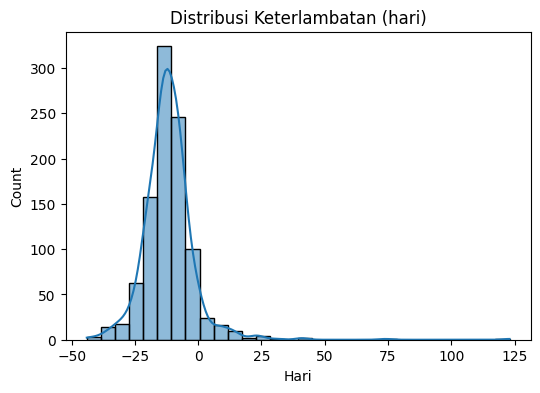

In [38]:
# --- 4. Distribusi keterlambatan ---
plt.figure(figsize=(6,4))
sns.histplot(olist["delay_days"].dropna(), bins=30, kde=True)
plt.title("Distribusi Keterlambatan (hari)")
plt.xlabel("Hari")
plt.show()

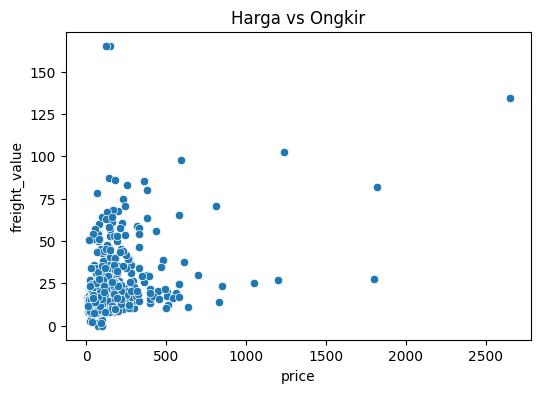

In [39]:
# --- 5. Analisis harga & ongkir ---
plt.figure(figsize=(6,4))
sns.scatterplot(data=olist, x="price", y="freight_value")
plt.title("Harga vs Ongkir")
plt.show()

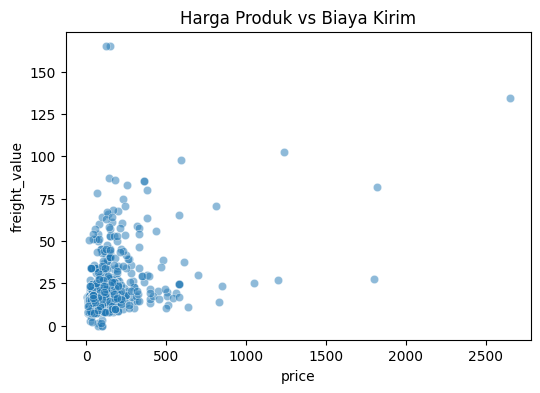

In [40]:
# --- 6. Analisis harga & biaya kirim ---
plt.figure(figsize=(6,4))
sns.scatterplot(data=olist, x="price", y="freight_value", alpha=0.5)
plt.title("Harga Produk vs Biaya Kirim")
plt.show()

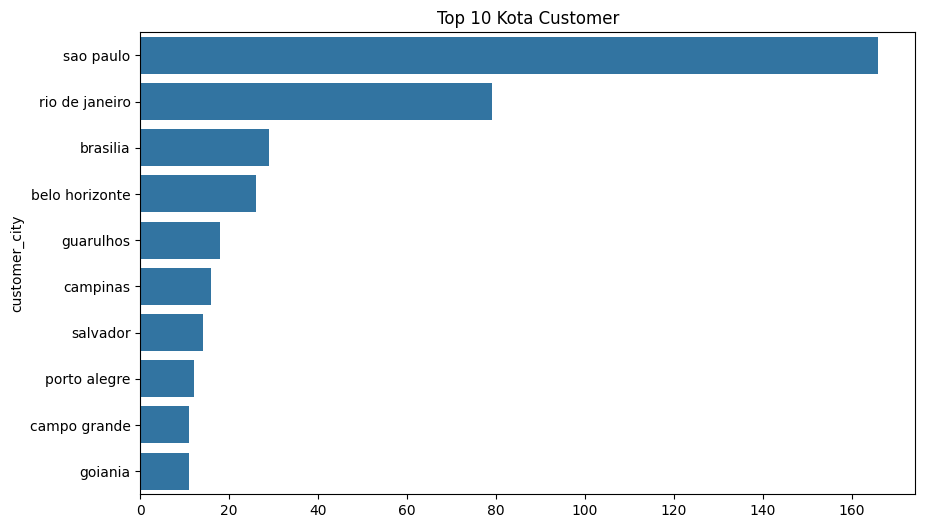

In [41]:
# --- 6. Analisis geografis (customer) ---
plt.figure(figsize=(10,6))
top_cities = olist["customer_city"].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Kota Customer")
plt.show()

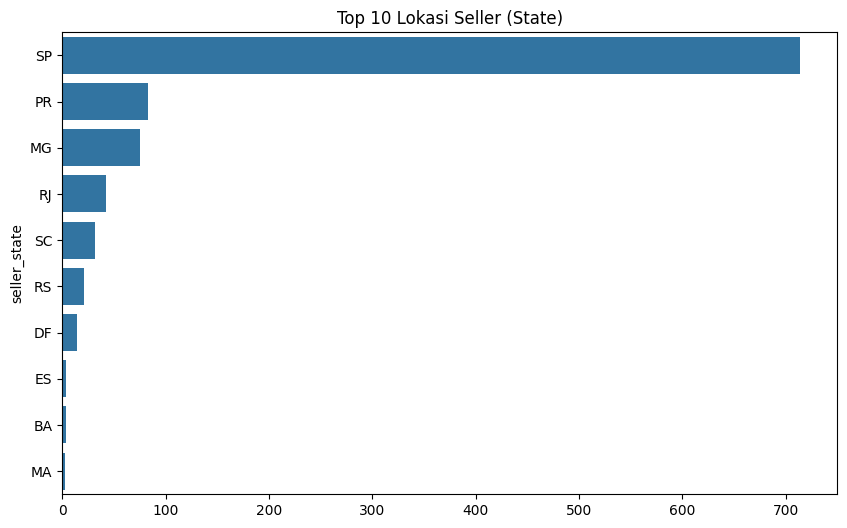

In [42]:
# --- 7. Analisis geografis (seller) ---
plt.figure(figsize=(10,6))
top_seller_states = olist["seller_state"].value_counts().head(10)
sns.barplot(x=top_seller_states.values, y=top_seller_states.index)
plt.title("Top 10 Lokasi Seller (State)")
plt.show()

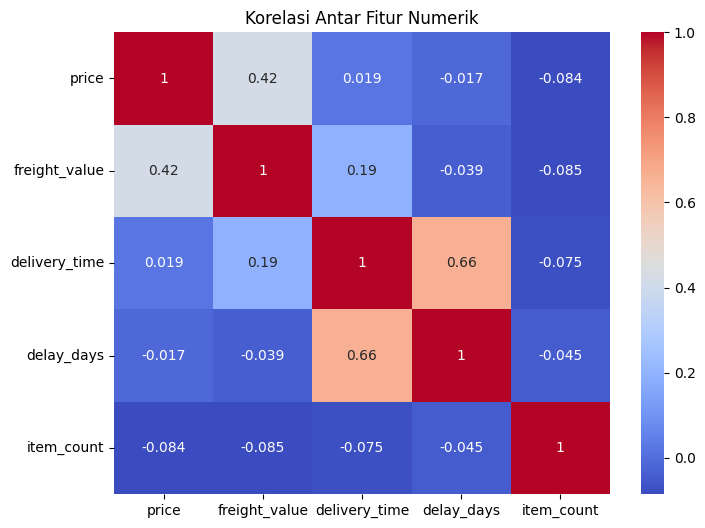

In [43]:
# --- 7. Korelasi antar fitur numerik ---
plt.figure(figsize=(8,6))
sns.heatmap(olist[["price","freight_value","delivery_time","delay_days","item_count"]].corr(), annot=True, cmap="coolwarm")
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

In [44]:
# Rata-rata lama pengiriman per kota
city_delivery = (
    olist.groupby("customer_city")["delivery_time"]
    .mean()
    .dropna()  # buang kota yang tidak ada delivery_time
)

print(city_delivery)

customer_city
abelardo luz            46.000000
aguas formosas          14.000000
alagoinhas              19.333333
alcobaca                11.000000
alfenas                  7.000000
                          ...    
vitoria da conquista    17.000000
vitoria do mearim       26.000000
volta grande            11.000000
volta redonda           18.000000
votuporanga              5.000000
Name: delivery_time, Length: 354, dtype: float64


karna ada order yang gagal/cancel yang tidak memiliki delivery time, sehingga ada na. Fokus visualisasi pada lama pengiriman, maka orderan yang dicancel/gagal dibuang.

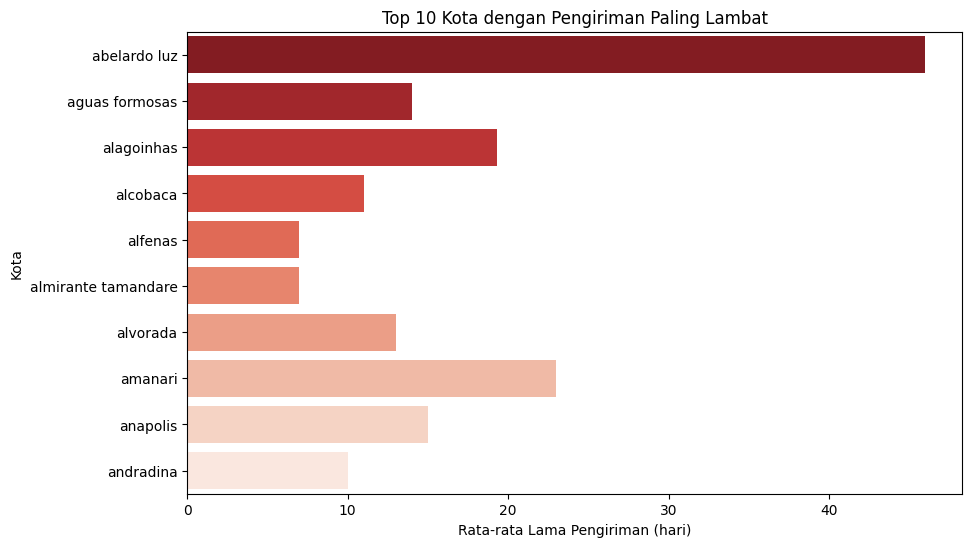

In [45]:
# --- 8. Lama Pengiriman disetiap kota ---

# Top 10 kota paling lambat
plt.figure(figsize=(10,6))
sns.barplot(x=city_delivery.head(10).values, y=city_delivery.head(10).index, palette="Reds_r")
plt.title("Top 10 Kota dengan Pengiriman Paling Lambat")
plt.xlabel("Rata-rata Lama Pengiriman (hari)")
plt.ylabel("Kota")
plt.show()

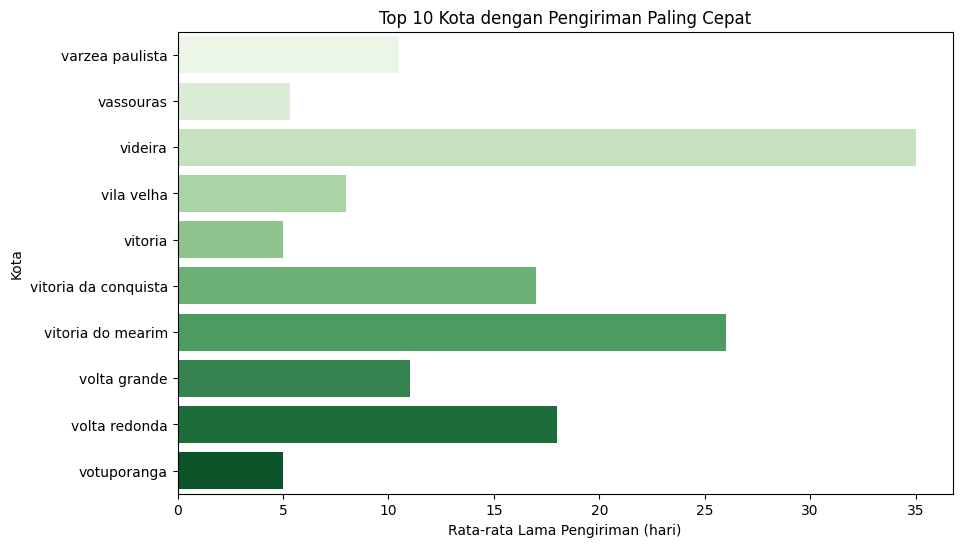

In [46]:
# Top 10 kota paling cepat
plt.figure(figsize=(10,6))
sns.barplot(x=city_delivery.tail(10).values, y=city_delivery.tail(10).index, palette="Greens")
plt.title("Top 10 Kota dengan Pengiriman Paling Cepat")
plt.xlabel("Rata-rata Lama Pengiriman (hari)")
plt.ylabel("Kota")
plt.show()